<a href="https://www.kaggle.com/code/mugishapacifique/mnist-digit-classification-acc-0-993?scriptVersionId=310215088" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
pip install idx2numpy

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7904 sha256=1bbb915d804c34be6171e0fb091d94d5841f3ca9e9abcae0787ad683f5ffe403
  Stored in directory: /root/.cache/pip/wheels/87/e5/e7/70fc742b3645ddf9d392f766feccbcc95cb3a3c806f8588af0
Successfully built idx2numpy
Note: you may need to restart the kernel to use updated packages.


# IMPORTING LIBRARIES

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.optim.lr_scheduler as lr_scheduler 
import idx2numpy
import os
import pandas as pd
import warnings
import random
warnings.filterwarnings('ignore')

# LOADING AND PREPAIRING THE MNIST DATASET


In [3]:
warnings.filterwarnings('ignore')
def set_seed(seed=42):
    """Set all random seeds for reproducibility."""
    # Python built-in random
    random.seed(seed)
    
    # Numpy
    np.random.seed(seed)
    
    # Torch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    
    # Deterministic settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Environment variable (some other sources of randomness)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Global seed set to {seed}")

# Set the seed at the start
set_seed(400)

Global seed set to 400


In [4]:

data_dir = '/kaggle/input/mnist-dataset'

# Load .idx files
train_images = idx2numpy.convert_from_file(os.path.join(data_dir, 'train-images.idx3-ubyte'))
train_labels = idx2numpy.convert_from_file(os.path.join(data_dir, 'train-labels.idx1-ubyte'))
test_images = idx2numpy.convert_from_file(os.path.join(data_dir, 't10k-images.idx3-ubyte'))
test_labels = idx2numpy.convert_from_file(os.path.join(data_dir, 't10k-labels.idx1-ubyte'))

# Normalize and convert to tensors
train_images = torch.tensor(train_images, dtype=torch.float32) / 255.0
test_images = torch.tensor(test_images, dtype=torch.float32) / 255.0
train_labels = torch.tensor(train_labels, dtype=torch.long)
test_labels = torch.tensor(test_labels, dtype=torch.long)
print(train_images.shape)

# NOW we are reshaping images to match (N, 1, 28, 28) format for CNNs
train_images = train_images.unsqueeze(1)
test_images = test_images.unsqueeze(1)
print(train_images.shape)

# creating a tensor dataset
train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)


torch.Size([60000, 28, 28])
torch.Size([60000, 1, 28, 28])


In [5]:

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


# VISUALIZING SOME OF THE LOADED DATA

***Get first batch of images***


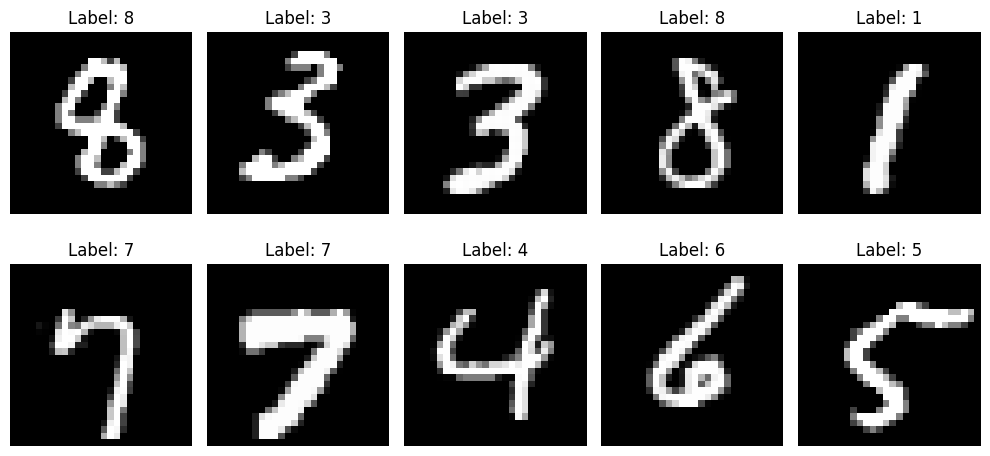

In [6]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].permute(1, 2, 0),cmap="gray") 
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# DEFINING A CNNs MODEL

In [7]:
class simpleCNN(nn.Module):
    def __init__(self):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ELU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x



        

# INITIALIZING THE MODEL ,LOSS FUNCTON AND OPTIMIZER

In [8]:
device ="cuda" if torch.cuda.is_available() else "cpu"
model= simpleCNN().to(device)
criterrion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# TRAINING THE MODEL

In [9]:
#training
from tqdm import tqdm
model.train()
best_acc = 0
patience = 7
count = 0
correct=0
total=0
predictions=[]
actuals=[]
epochs=25
for epoch in range(epochs):
    train_loader = tqdm(train_loader, 'running training')
    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)

        optimizer.zero_grad()
        output=model(images)
        loss=criterrion(output,labels)
        loss.backward()
        optimizer.step()
    scheduler.step()
    with torch.no_grad():
        for images,labels in test_loader:
            images,labels=images.to(device),labels.to(device)
            output=model(images)
            _,predicted=torch.max(output.data,1)     
            total += labels.size(0)
            ev_loss = criterrion(output, labels)
            correct +=(predicted==labels).sum().item()
            predictions.extend(predicted.cpu().numpy())
            actuals.extend(labels.cpu().numpy())
        if (correct/total) > best_acc:
            best_acc = (correct/total)
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'model save with accuracy : {best_acc}')
            count = 0
        else:
            count += 1
            if count >= patience:
                print('eary stopping')
                break
    print(f"for the {epoch+1}/{epochs} the loss is :{ev_loss.item():.5f}")
      

running training: 100%|██████████| 938/938 [00:41<00:00, 22.56it/s]


model save with accuracy : 0.9786
for the 1/25 the loss is :0.00223


running training: 100%|██████████| 938/938 [00:46<00:00, 20.00it/s]


model save with accuracy : 0.9799
for the 2/25 the loss is :0.00061


running training: 100%|██████████| 938/938 [00:41<00:00, 22.60it/s]


...

model save with accuracy : 0.9879478260869565
for the 23/25 the loss is :0.00008


running training: 100%|██████████| 938/938 [00:41<00:00, 22.77it/s]


model save with accuracy : 0.9880333333333333
for the 24/25 the loss is :0.00033


running training: 100%|██████████| 938/938 [00:41<00:00, 22.65it/s]


model save with accuracy : 0.988124
for the 25/25 the loss is :0.00006


# EVALUATING THE MODEL

In [10]:
# testing the model on the test set

model.eval()
correct=0
total=0
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
predictions=[]
actuals=[]

with torch.no_grad():
    for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        output=model(images)
        _,predicted=torch.max(output.data,1)     
        total += labels.size(0)
        correct +=(predicted==labels).sum().item()
        predictions.extend(predicted.cpu().numpy())
        actuals.extend(labels.cpu().numpy())
print(f"the accuracy is:{(100*correct)/total:.4f}")



the accuracy is:99.3100


# VISUAL EVALUATION

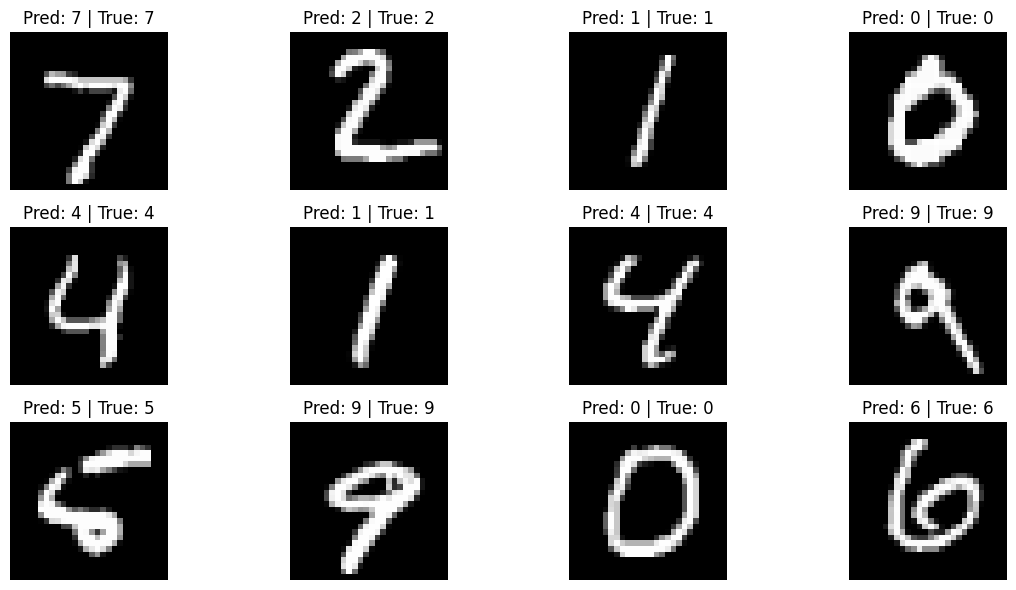

In [11]:


model.eval()

# Getting a batch of test images
images, labels = next(iter(test_loader))

images, labels = images.to(device), labels.to(device)

# Getting model predictions
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# we Move to CPU and convert to numpy for plotting 
# (we do this because some times we might be working on gpu)
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# we Plot the first 12 images with their predictions
fig = plt.figure(figsize=(12, 6))
for idx in range(12):
    ax = fig.add_subplot(3, 4, idx+1)
    img = images[idx].squeeze()  # remove channel dimension (1,28,28) → (28,28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {preds[idx].item()} | True: {labels[idx].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()


# CREATING A SUBMISSION CSV

In [12]:
'''
# ImageId starts at 1
image_ids = list(range(1, len(predictions) + 1))

submission_df = pd.DataFrame({
    'ImageId': image_ids,
    'actual': actuals,
    'Label': predictions
})

# now we Save to CSV fro submiting after download.
submission_df.to_csv('submission.csv', index=False)

'''

In [13]:
'''
data_reading=pd.read_csv('submission.csv')
data_reading_df=pd.DataFrame(data=data_reading)
print(data_reading_df.head())
'''

   ImageId  actual  Label
0        1       7      7
1        2       2      2
2        3       1      1
3        4       0      0
4        5       4      4


![upvote_complesed.png](attachment:167741b9-c62d-4baf-ad6b-bb67db91c85f..png)